In [1]:
# Imports
from matplotlib.animation import FuncAnimation
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.signal import resample
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import pandas as pd
import numpy as np
import joblib
import json

In [2]:
normalized_df = pd.read_parquet("./data/normalized_pca.parquet")

In [3]:
# Get frame-wise mean for each PC
pcs = ["PC1", "PC2", "PC3"]
mean_df = normalized_df.groupby("frame_norm")[["PC1", "PC2", "PC3"]].mean().reset_index()
mean_df.rename(columns = {'PC1' : 'PC1_mean', 'PC2' : 'PC2_mean', 'PC3' : 'PC3_mean'}, inplace = True)

# Merge mean with normalized
merged = normalized_df.merge(mean_df, on="frame_norm", how="left")

# Calculate difference between mean pitch and individual pitch for each frame
for pc in pcs:
    merged[f"{pc}_diff"] = merged[pc] - merged[f"{pc}_mean"]

merged.head(2)

,frame_norm,PC1,PC2,PC3,userID,sessionID,pitchNum,height,weight,pitchType,pitchSpeed,PC1_mean,PC2_mean,PC3_mean,PC1_diff,PC2_diff,PC3_diff
0,0.0,-5.484197,3.713685,-2.025996,000002,003034,002,73,207,FF,80.9,-5.022185,3.597697,-1.940412,-0.462013,0.115988,-0.085585
1,1.0,-5.535786,3.764470,-2.127300,000002,003034,002,73,207,FF,80.9,-5.046363,3.549513,-1.919048,-0.489423,0.214957,-0.208252


In [4]:
# Find max and min values for each PC
agg = (
    merged
    .groupby(["userID", "sessionID", "pitchNum"], as_index=False)
    .agg(
        PC1_max=("PC1_diff", "max"),
        PC1_min=("PC1_diff", "min"),
        PC2_max=("PC2_diff", "max"),
        PC2_min=("PC2_diff", "min"),
        PC3_max=("PC3_diff", "max"),
        PC3_min=("PC3_diff", "min"),
    )
)
# display(agg)

poi_records = []

# Keep track of which PC/max/min selected each pitch
for pc in [1,2,3]:
    for extreme in ["max", "min"]:
        col = f"PC{pc}_{extreme}"
        row = agg.loc[agg[col].idxmax() if extreme == "max" else agg[col].idxmin()]
        poi = (row["userID"], row["sessionID"], row["pitchNum"])
        desc = f"PC{pc} {extreme}"
        # Check if POI already in records
        existing = next((r for r in poi_records if r["pitch_of_interest"] == poi), None)
        if existing:
            existing["description"] += f", {desc}"
        else:
            poi_records.append({"POI": len(poi_records) + 1, "pitch_of_interest": poi, "description": desc})

poi_df = pd.DataFrame(poi_records)
pitches_of_interest = poi_df["pitch_of_interest"]
pitch_of_interest = []
for pitch in pitches_of_interest:
    pitch_of_interest.append(pitch)
display(poi_df)

,POI,pitch_of_interest,description
0,1,"(001607, 002981, 006)",PC1 max
1,2,"(001659, 003232, 011)",PC1 min
2,3,"(000919, 001393, 001)",PC2 max
3,4,"(001756, 003172, 004)",PC2 min
4,5,"(000090, 003044, 004)",PC3 max
5,6,"(000906, 001371, 011)",PC3 min


In [5]:
# Build a mapping: POI -> list of PCs where it is min/max
poi_to_pcs = {}
for idx, r in enumerate(poi_records):
    # extract PC numbers from description like "PC1 max, PC3 min"
    pcs_for_poi = [d.split()[0] for d in r["description"].split(", ")]
    poi_to_pcs[r["pitch_of_interest"]] = pcs_for_poi

# Assign a color to each POI
poi_colors = cm.tab10.colors[:len(pitch_of_interest)]
poi_to_color = {poi: poi_colors[i] for i, poi in enumerate(pitch_of_interest)}

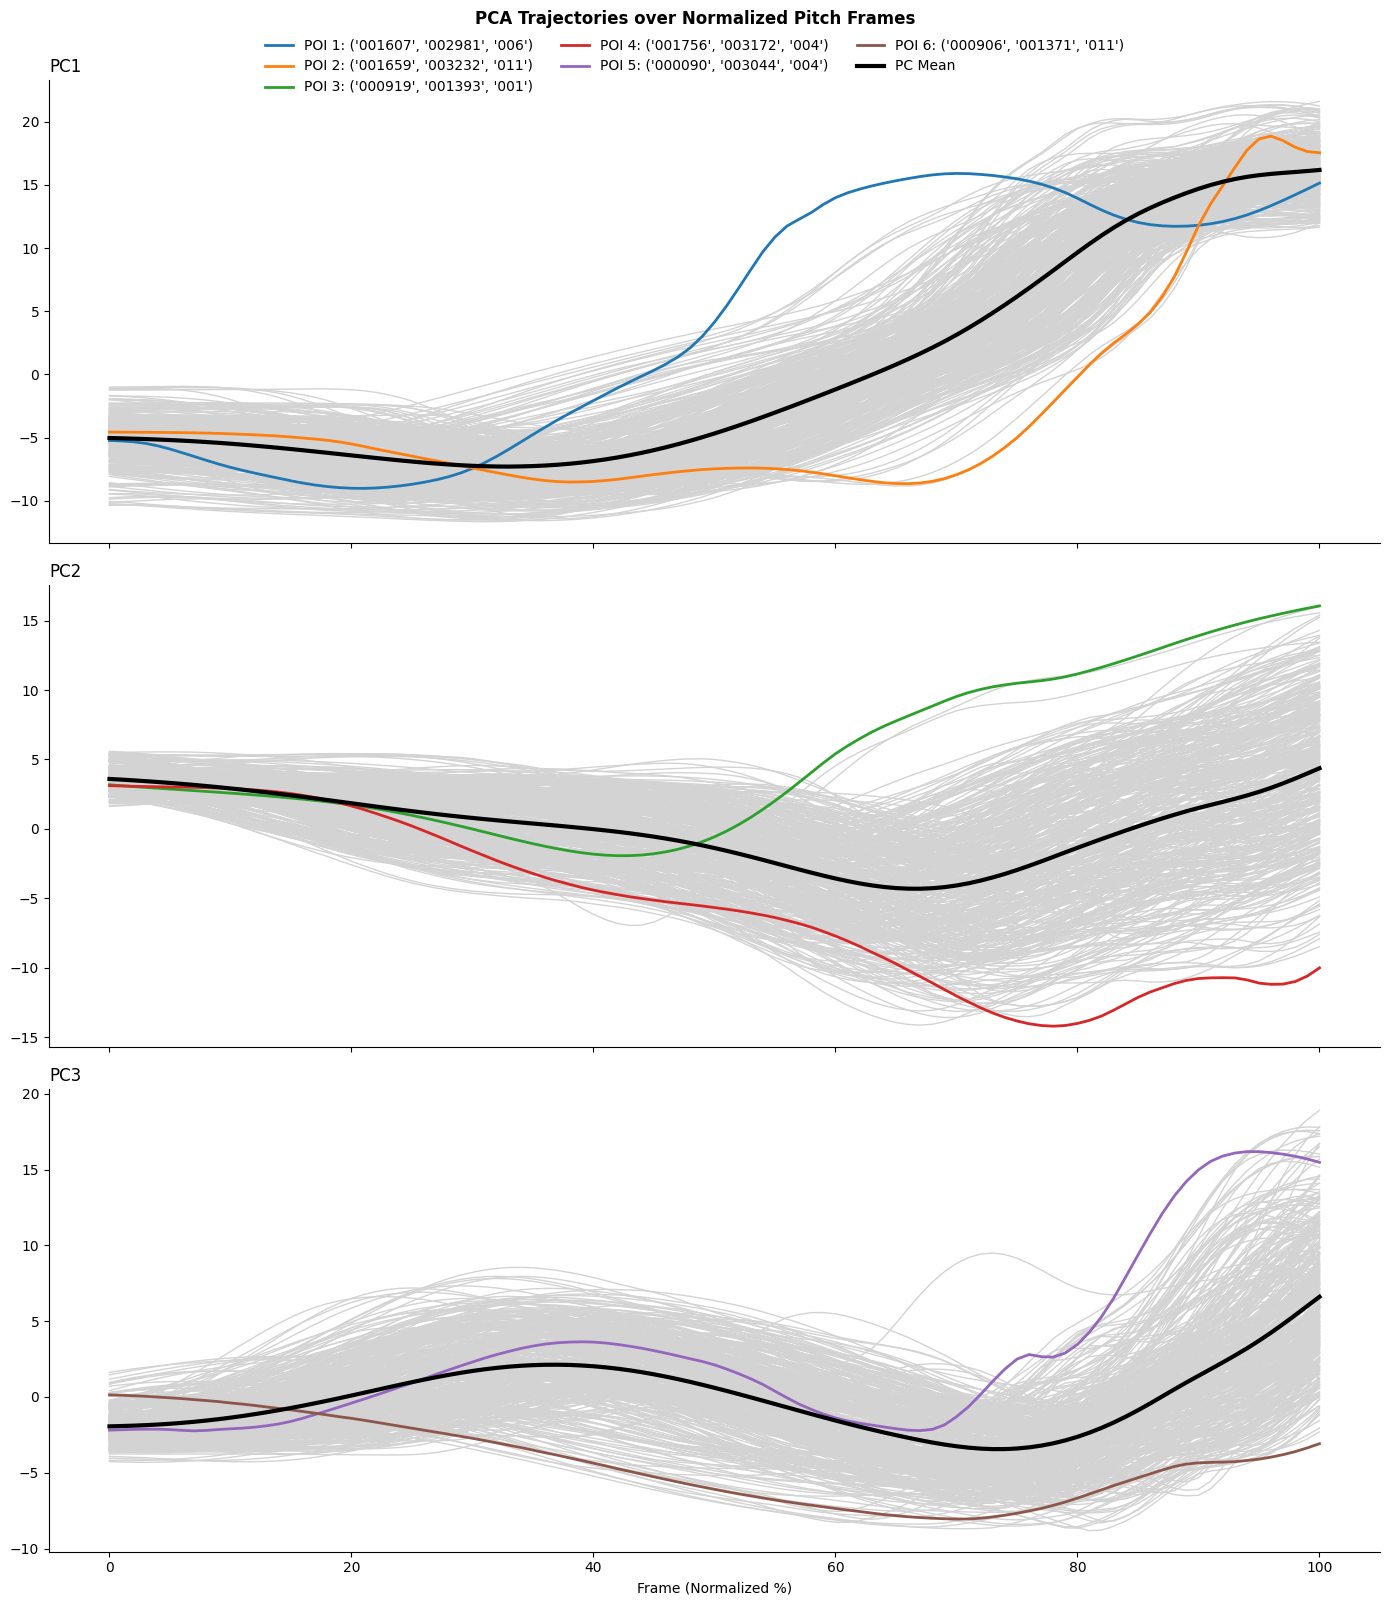

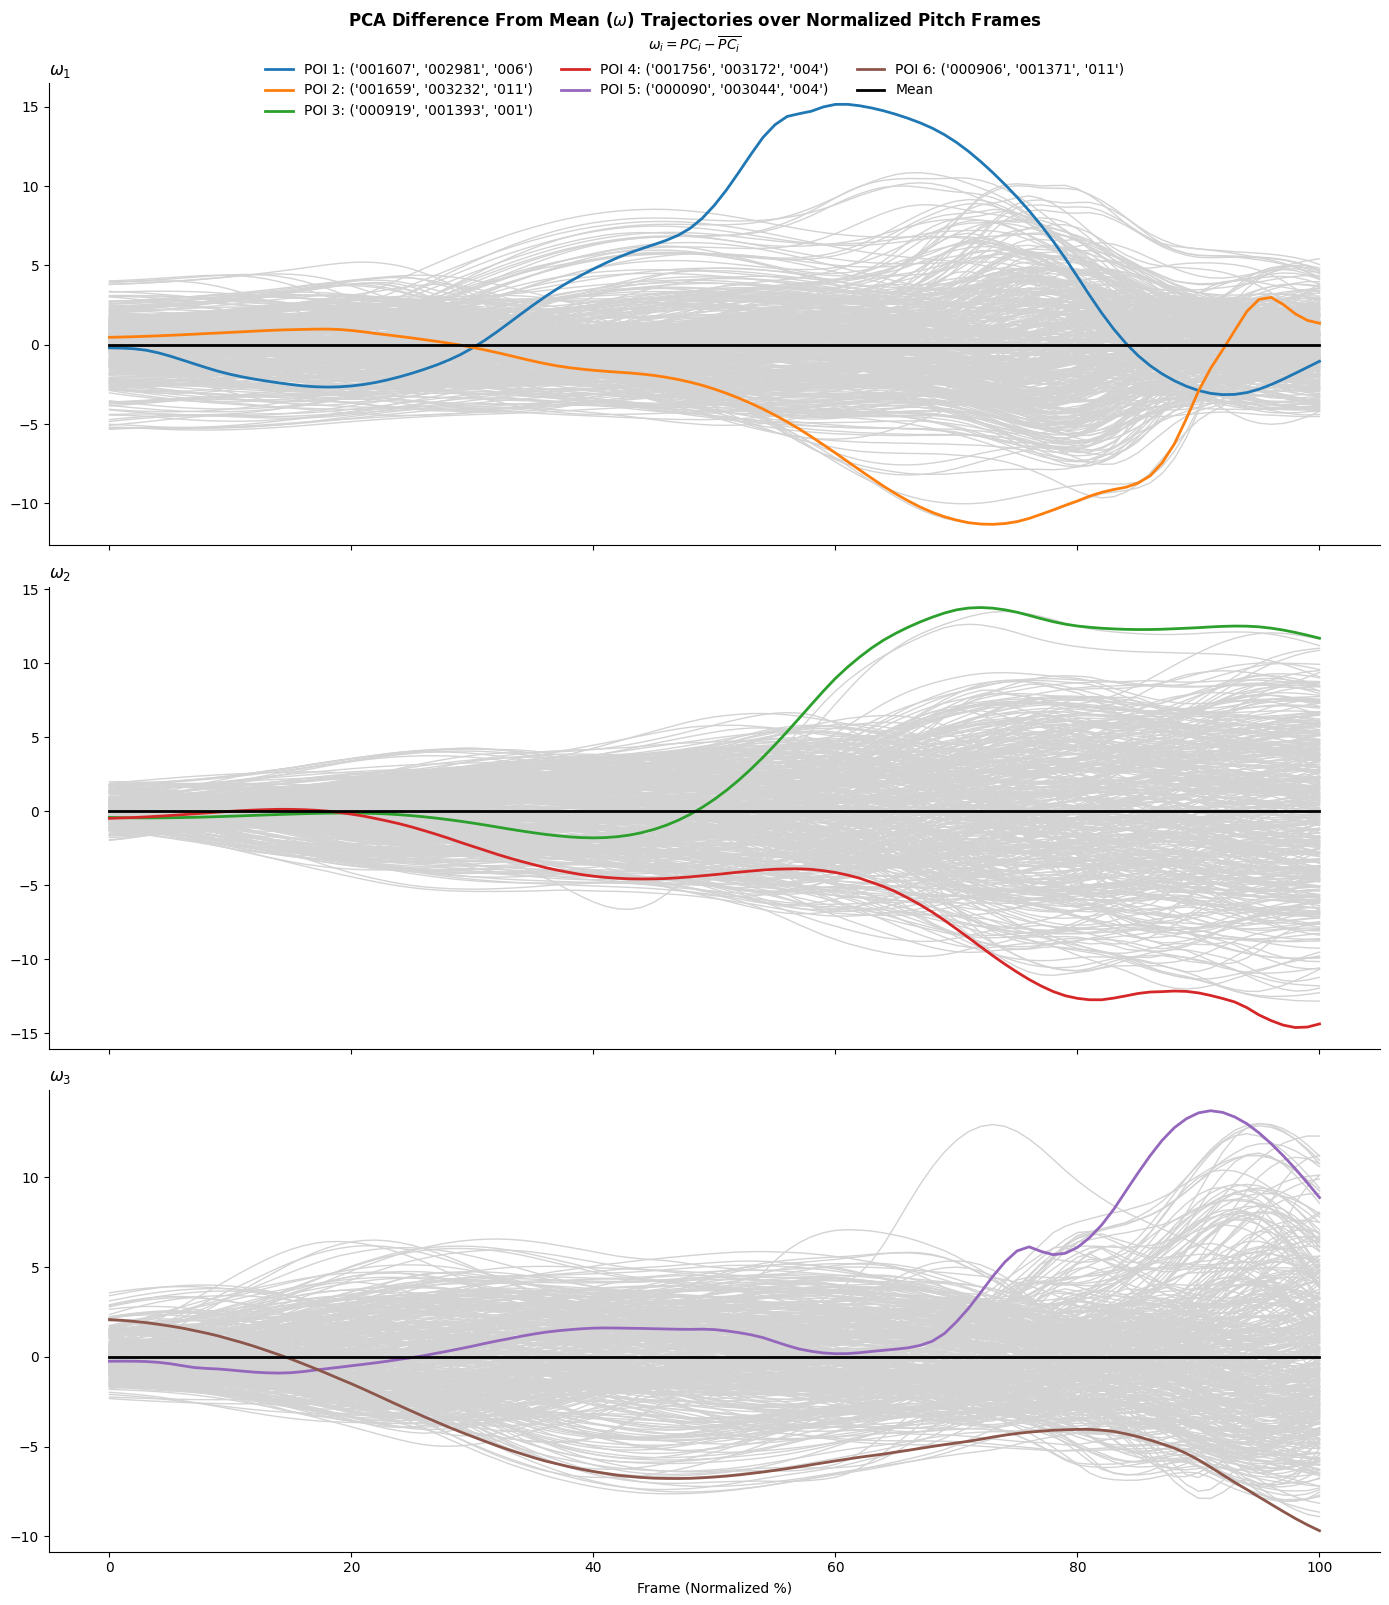

In [6]:
from plots import plot_pca, plot_diffs
plot_pca(normalized_df, poi_to_color, poi_to_pcs, pitch_of_interest)
plot_diffs(merged, poi_to_color, poi_to_pcs, poi_records)

In [7]:
data = pd.read_parquet("../data/cleaned_data.parquet")

In [8]:
from animations import animate

for poi in pitch_of_interest:
    userID, sessionID, pitchNum = poi

    print(f"Animating: {poi}")

    sel = data[
        (data['userID'] == userID) &
        (data['sessionID'] == sessionID) &
        (data['pitchNum'] == pitchNum)
    ]

    if sel.empty:
        print(f"No rows for {poi}, skipping.")
        continue

    # animate(sel, animation_type='real')

Animating: ('001607', '002981', '006')
Animating: ('001659', '003232', '011')
Animating: ('000919', '001393', '001')
Animating: ('001756', '003172', '004')
Animating: ('000090', '003044', '004')
Animating: ('000906', '001371', '011')


In [9]:
pivot_df = pd.read_parquet("../data/pivot.parquet").reset_index()
marker_cols = pivot_df.columns[9:]

In [10]:
pca = joblib.load('./data/pca_model.joblib')
scaler = joblib.load("./data/scaler_model.joblib")

# Assuming 'pca' is your fitted PCA object and 'marker_cols' lists your features
loadings_df = pd.DataFrame(
    pca.components_,
    columns=marker_cols,
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)

loadings_df.reset_index(inplace = True)
loadings_df.rename(columns = {'index': 'PC'}, inplace= True)
melted_loadings = loadings_df.melt(id_vars = 'PC', var_name = 'coord_marker', value_name = 'value')
melted_loadings['abs_value'] = np.abs(melted_loadings['value'])

melted_loadings['marker'] = melted_loadings['coord_marker'].str.split('_').str.get(1)

marker_contrib = (
    melted_loadings
    .groupby(['PC', 'marker'])
    .agg(total_contrib=('value', lambda x: np.sum(np.abs(x))))
    .reset_index()
)

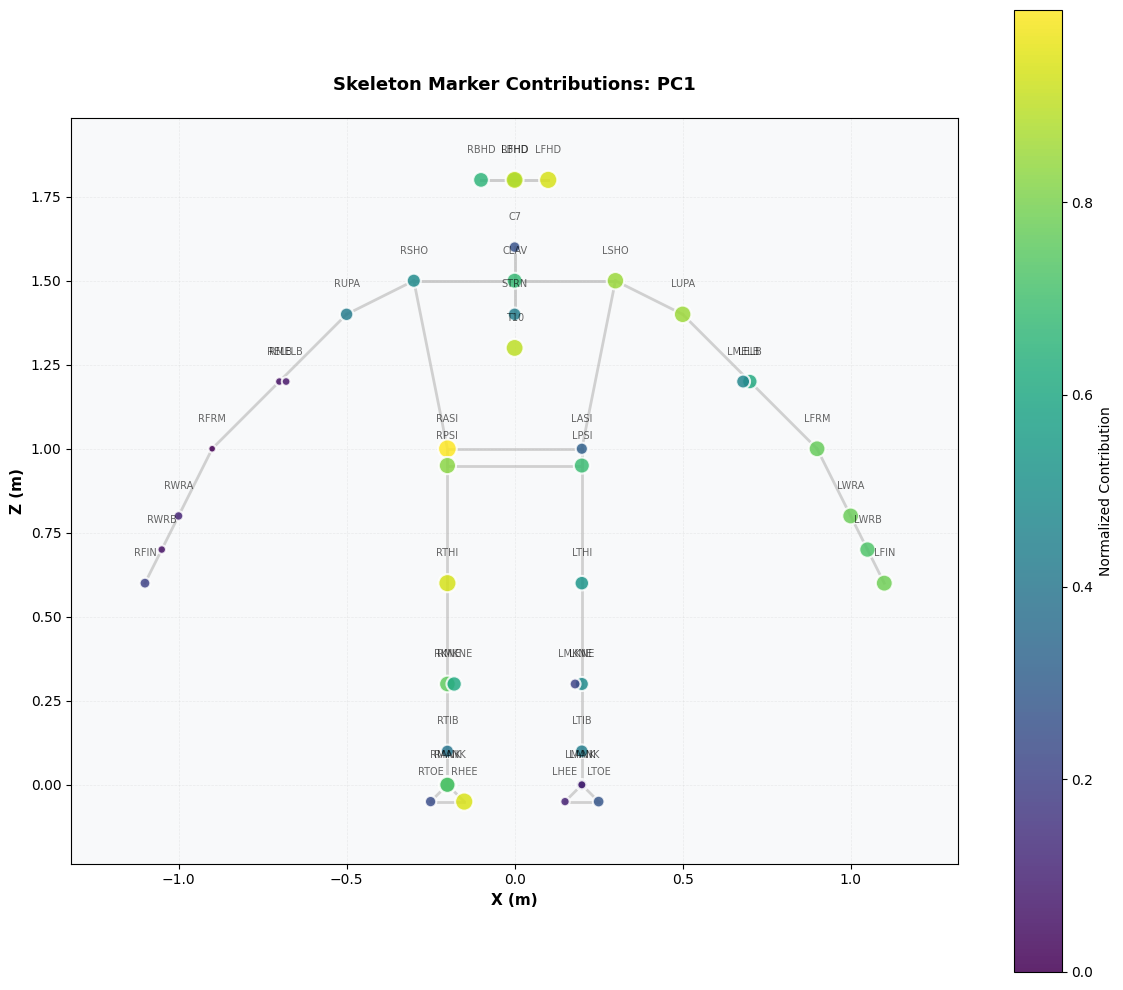

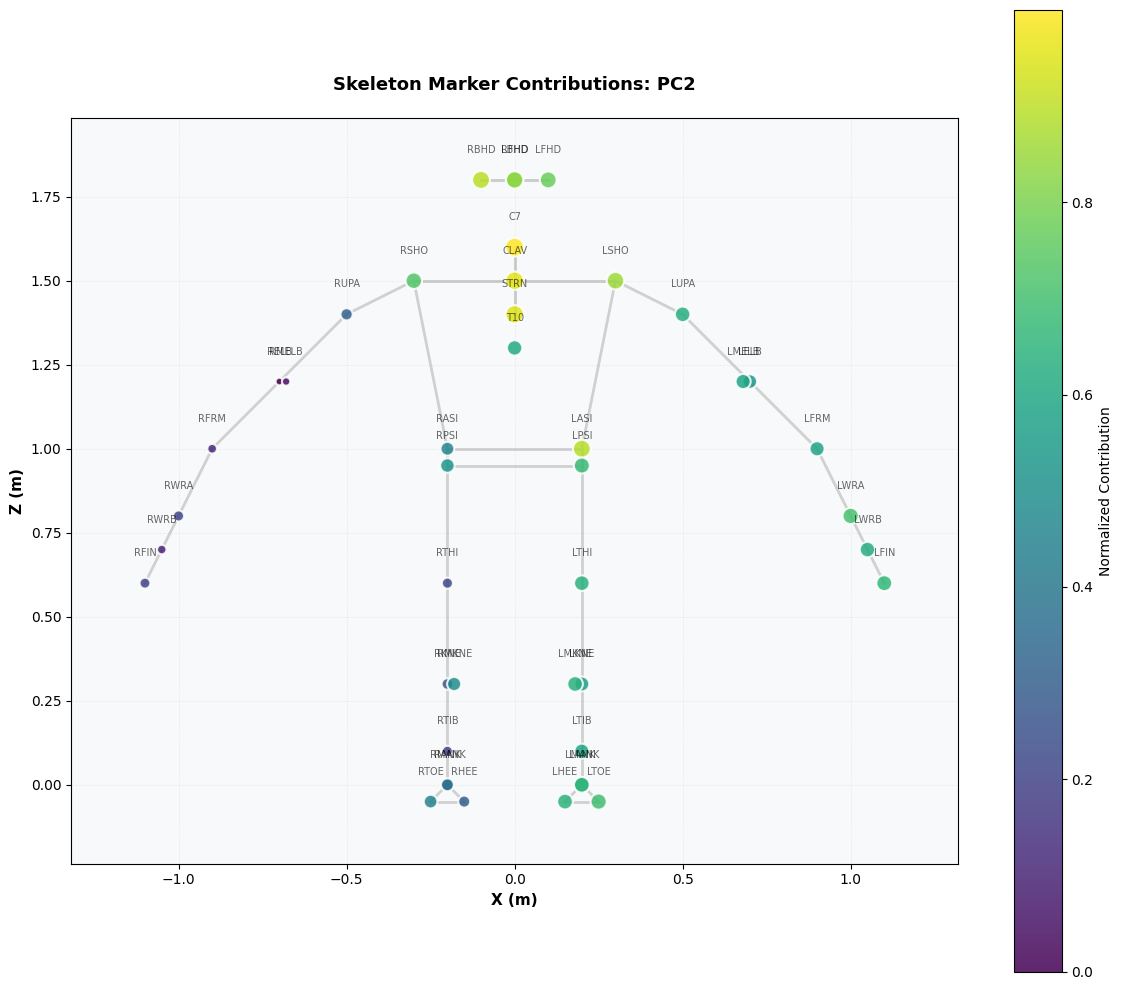

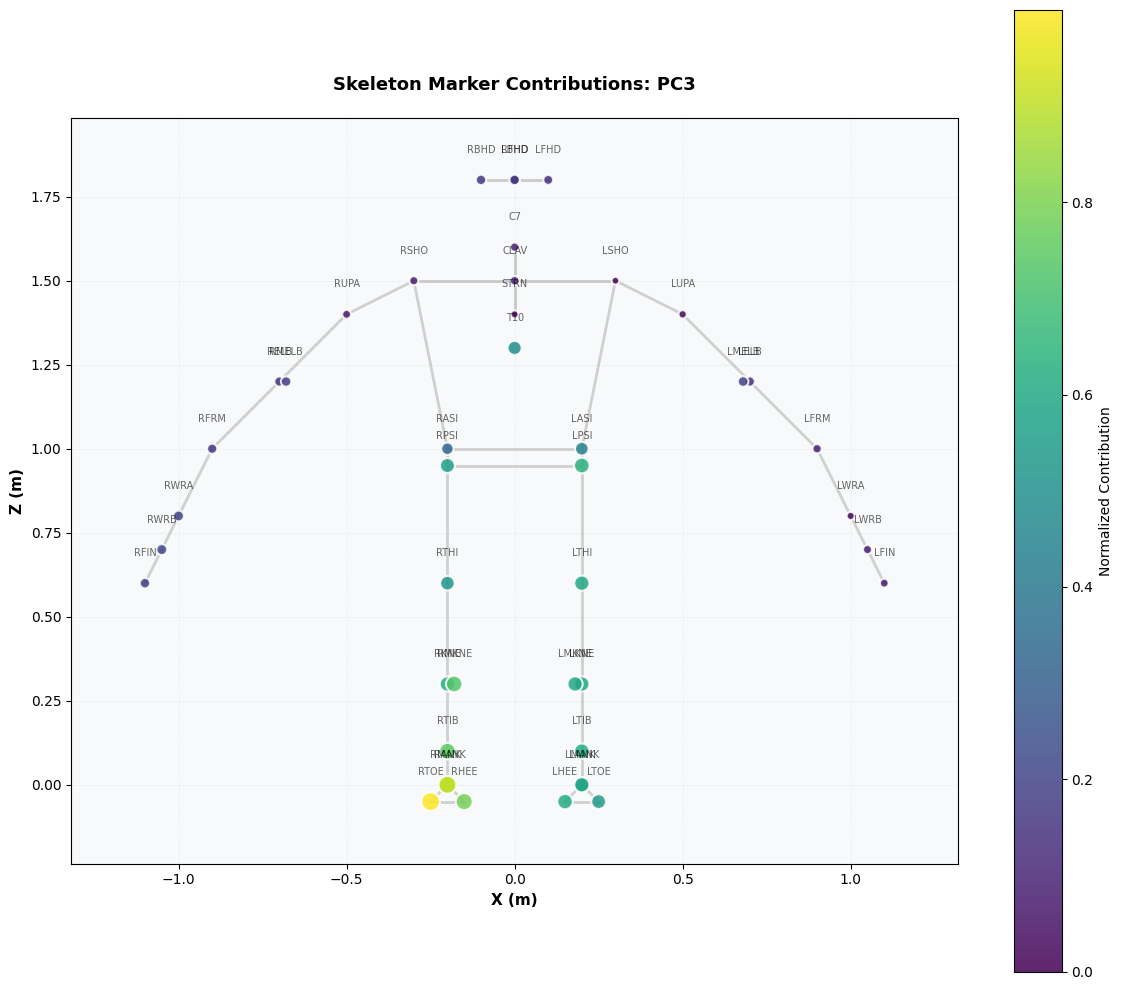

In [11]:
from plots import plot_pc_contribution_skeleton
for pc in ['PC1', 'PC2', 'PC3']:
    plot_pc_contribution_skeleton(marker_contrib, pc = pc, show_labels = True)